# Comparison of Moments: OP vs WS Formalism
This notebook plots the Ergotropy (1st moment), Variance (2nd moment), and Third Moment against N using data extracted from both the OP and WS formalisms.

In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


In [3]:
############
# Parameter
############

N_arr = np.arange(2, 51, 1)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

### Operator Method

/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, erg/Eb=0.964113651149, Variance=5.7360130333e-01, ThirdMoment=2.7069069669e+00, Skewness=-2.5398228176e-01
N= 3, τ=0.5807, Eb=1.683140, Ergotropy=1.636665, erg/Eb=0.972388170139, Variance=8.8272458818e-01, ThirdMoment=8.4386114649e+00, Skewness=-3.3719738990e-01
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.270698, erg/Eb=0.977394390424, Variance=1.1937538485e+00, ThirdMoment=1.9355031661e+01, Skewness=-3.7170886247e-01
N= 5, τ=0.4696, Eb=2.973274, Ergotropy=2.916091, erg/Eb=0.980767557910, Variance=1.5059273173e+00, ThirdMoment=3.7256270476e+01, Skewness=-3.8702141779e-01
N= 6, τ=0.4344, Eb=3.629995, Ergotropy=3.569077, erg/Eb=0.983217925261, Variance=1.8187600085e+00, ThirdMoment=6.3974105035e+01, Skewness=-3.9292601571e-01
N= 7, τ=0.4065, Eb=4.292903, Ergotropy=4.228811, erg/Eb=0.985070184249, Variance=2.1321818007e+00, ThirdMoment=1.0144478975e+02, Skewness=-3.9446706151e-01
N= 8, τ=0.3835, Eb=4.959030, Ergotropy=4.892298, erg/Eb=0.986543

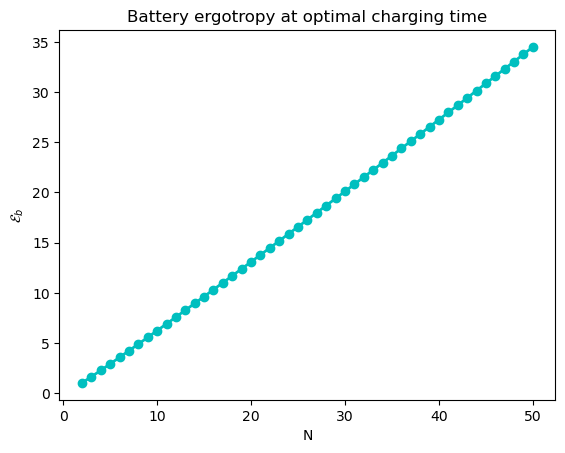

In [5]:
######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14)         ## ODE solver options
    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full, options=opts)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio, E_moment3, E_skewness = [], [], [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
        
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    # e_vals = np.arange(N + 1) * ω0
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB, r_vecs[i]) for i in range(len(r_vals)))

    ΔE2 = W_2 - (E_erg)**2

    #########################################################
    # Third moment of the ergotropy operator
    # <(E_B)^3> = Tr[rho (H - H_pass)^3]
    #########################################################

    # ---------- first term ----------
    # Tr[rho H_B^3]
    term1 = qt.expect(HB**3, rho_b)

    # ---------- second term ----------
    # -3 * Σ_j ε_j r_j <r_j|H_B^2|r_j>
    term2 = -3 * sum(e_vals[j] * r_vals[j] * qt.expect(HB**2, r_vecs[j]) for j in range(len(r_vals)))

    # ---------- third term ----------
    # +3 * Σ_j ε_j^2 r_j <r_j|H_B|r_j>
    term3 = 3 * sum((e_vals[j]**2) * r_vals[j] * qt.expect(HB, r_vecs[j]) for j in range(len(r_vals)))

    # ---------- fourth term ----------
    # - Σ_j r_j ε_j^3
    term4 = -sum(r_vals[j] * (e_vals[j]**3) for j in range(len(r_vals)))

    # Third raw moment
    W_3 = term1 + term2 + term3 + term4

    #########################################################
    # Third central moment (skewness numerator)
    # μ3 = <E^3> - 3<E^2><E> + 2<E>^3
    #########################################################

    mu3 = W_3 - 3 * W_2 * E_erg + 2 * (E_erg**3)

    #########################################################
    # Normalized skewness
    #########################################################

    if ΔE2 > 1e-14:
        skewness = mu3 / (ΔE2**1.5)
    else:
        skewness = 0.0
    
    ΔE = np.sqrt(ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    E_moment3.append(W_3)

    E_skewness.append(skewness)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f}, Variance={ΔE2:.10e}, ThirdMoment={W_3:.10e}, Skewness={skewness:.10e}")

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

### Work Statistics Method

In [13]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.special import comb
from itertools import product

############
# parameters
############

N_arr = np.arange(2, 51, 1)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2,'+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2,'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    IB = qt.qeye(N+1)
    H = ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))
    return H, HB

################
# Passive state
################

def passive_state(rho, H):
    r_val, r_vec = rho.eigenstates()
    
    # Keep formalism intact from the notebook
    r_val = np.maximum(r_val, 0)
    r_val = r_val / np.sum(r_val)
    
    idx = np.argsort(r_val)[::-1]          # descending order
    r_val = r_val[idx]

    e_val, e_vec = H.eigenstates()         # ascending order

    return np.sum(r_val[i] * e_vec[i] * e_vec[i].dag()
               for i in range(len(r_val)))

########################
# ergotropy calculation
########################

def ergotropy(ρ, H):
    ρ_p = passive_state(ρ, H)
    return qt.expect(H, ρ) - qt.expect(H, ρ_p)

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

##############
# Pnm matrix
##############

def pnm_matrix(rho, H):
    r_val, r_vec = rho.eigenstates()
    
    # --- CORRECTION STARTS HERE ---
    # Clip numerical noise to prevent negative probabilities
    r_val = np.maximum(r_val, 0) 
    # Renormalize 
    r_val = r_val / np.sum(r_val)
    # --- CORRECTION ENDS HERE ---
    
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)

############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

#########################################################
# Extract Dicke-sector probabilities
#########################################################

def extract_Cn_dicke(rho_b, N):
    """
    Extract probabilities |C_n|^2
    in the symmetric Dicke basis.

    Assumes rho_b already lives in
    the Dicke subspace of dimension N+1.
    """

    diag = np.real(rho_b.diag())

    Cn = np.zeros(N+1)

    #####################################################
    # In Dicke basis:
    #
    # index n corresponds to
    # |N/2, n-N/2>
    #####################################################

    for n in range(N+1):

        Cn[n] = diag[n]

    #####################################################
    # normalize
    #####################################################

    Cn = Cn / np.sum(Cn)

    return Cn
    
#########################################################
# Dicke-basis probability distribution of energy changes
#########################################################

def dicke_projector(N, n_exc):
    """
    Symmetric Dicke state |N/2, n-N/2>
    with n excitations.
    """

    dim = 2**N

    dicke_vec = np.zeros(dim, dtype=complex)

    basis_states = list(product([0,1], repeat=N))

    indices = []

    for idx, state in enumerate(basis_states):
        if sum(state) == n_exc:
            indices.append(idx)
            
    degeneracy = len(indices)

    for idx in indices:
        dicke_vec[idx] = 1/np.sqrt(degeneracy)

    return qt.Qobj(dicke_vec, dims=[[2]*N,[1]*N])


#########################################################
# Probability distribution of energy differences
#########################################################

def probability_distribution_energy(rho_b, N, omegaB=1.0):
    """
    Computes

    P(ΔE) = Σ_n p_n δ(ΔE - (N-n)ωB)

    where

    p_n = |C_n|^2

    extracted from the battery density matrix.
    """

    # excitation probabilities
    Cn_prob = extract_Cn_dicke(rho_b, N)

    # possible energy differences
    deltaE = np.arange(-N, N+1) * omegaB

    P_deltaE = np.zeros(len(deltaE))

    #####################################################
    # Here:
    # initial excitation sector = m = N
    # final excitation sector = n
    # ΔE = (m-n)ωB = (N-n)ωB
    #####################################################
    
    for n in range(N+1):

        dE = (N - n) * omegaB

        idx = np.argmin(np.abs(deltaE - dE))

        P_deltaE[idx] += Cn_prob[n]

    return deltaE, P_deltaE

def moments_from_distribution(deltaE, P_deltaE):

    mean1 = np.sum(deltaE * P_deltaE)
    mean2 = np.sum((deltaE**2) * P_deltaE)
    mean3 = np.sum((deltaE**3) * P_deltaE)

    cumulant3 = mean3 - 3*mean2*mean1 + 2*(mean1**3)

    return mean1, mean2, mean3, cumulant3

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################

τ_list = []
# Ensure opts is instantiated globally to apply to all ODE evaluations uniformly
opts = qt.Options(atol=1e-16, rtol=1e-14)

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")


Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1].proj()

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(1)

    Eb = qt.expect(HB, ρb)

    # Generate the correct TPM probability matrix using the function from Cell 0.
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    erg = 0
    mean_E_sq = 0

    # Calculate TPM ergotropy and variance mapping to the full space
    for n in range(len(e_val)):
        En = e_val[n]
        for m in range(len(e_val)):
            
            # MAPPING TO FULL SPACE:
            # The full 2^N space has degeneracy 1 at E=0, and degeneracy N at E=ω0.
            # Since ρb has exactly N+1 non-zero eigenvalues, the passive state 
            # places the largest eigenvalue (m=0) in E=0, and the remaining N (m>0) in E=ω0.
            Em_pass = 0 if m == 0 else ω0
            
            ΔE = En - Em_pass
            
            erg += pnm[n, m] * ΔE
            mean_E_sq += pnm[n, m] * (ΔE**2)

    var = mean_E_sq - erg**2

    ratio = erg / Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.10f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)
    
Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list) 
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr
rel_fluc = np.sqrt(var_arr) / Eb_arr

#########################################################
# Reset moment lists
#########################################################

moment1_list = []
moment2_list = []
moment3_list = []
cumulant3_list = []


#########################################################
# Main loop
#########################################################

for N in N_arr:

    print(f"Running N = {N}")

    ############################################
    # Hamiltonian
    ############################################

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    ############################################
    # Initial state
    ############################################

    ψ0 = initial_state(N, nmax, "coherent")

    ############################################
    # Time evolution
    ############################################

    result = qt.sesolve(H, ψ0, tlist)

    states = result.states

    ############################################
    # Battery Hamiltonian
    ############################################

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    ############################################
    # Battery energy
    ############################################

    Eb_list = np.array([qt.expect(HB_full, st)for st in states])

    ############################################
    # Charging power
    ############################################

    power = np.divide(Eb_list, tlist, out=np.zeros_like(Eb_list), where=tlist!=0)

    τ_index = np.argmax(power)

    ψτ = states[τ_index]

    ############################################
    # Reduced battery density matrix
    ############################################

    rho_b = ψτ.ptrace(1)

    ############################################
    # Probability distribution
    ############################################

    deltaE, P_deltaE = probability_distribution_energy(rho_b, N, omegaB=ω0)

    ############################################
    # Moments
    ############################################

    μ1, μ2, μ3, κ3 = moments_from_distribution(deltaE,P_deltaE)

    moment1_list.append(μ1)
    moment2_list.append(μ2)
    moment3_list.append(μ3)
    cumulant3_list.append(κ3)


N= 2, τ=0.6822, E_B=1.043057
N= 3, τ=0.5807, E_B=1.655069
N= 4, τ=0.5158, E_B=2.279733
N= 5, τ=0.4696, E_B=2.912334
N= 6, τ=0.4344, E_B=3.549775
N= 7, τ=0.4065, E_B=4.191798
N= 8, τ=0.3835, E_B=4.835493
N= 9, τ=0.3642, E_B=5.481757
N=10, τ=0.3478, E_B=6.132016
N=11, τ=0.3334, E_B=6.781138
N=12, τ=0.3208, E_B=7.433067
N=13, τ=0.3096, E_B=8.086251
N=14, τ=0.2996, E_B=8.741809
N=15, τ=0.2905, E_B=9.396403
N=16, τ=0.2823, E_B=10.054526
N=17, τ=0.2747, E_B=10.709777
N=18, τ=0.2678, E_B=11.369316
N=19, τ=0.2614, E_B=12.028438
N=20, τ=0.2555, E_B=12.689983
N=21, τ=0.2500, E_B=13.351846
N=22, τ=0.2448, E_B=14.010757
N=23, τ=0.2400, E_B=14.674409
N=24, τ=0.2355, E_B=15.339291
N=25, τ=0.2312, E_B=16.000530
N=26, τ=0.2272, E_B=16.666467
N=27, τ=0.2234, E_B=17.331763
N=28, τ=0.2198, E_B=17.997735
N=29, τ=0.2164, E_B=18.665828
N=30, τ=0.2131, E_B=19.328548
N=31, τ=0.2100, E_B=19.995752
N=32, τ=0.2071, E_B=20.669229
N=33, τ=0.2042, E_B=21.329987
N=34, τ=0.2015, E_B=21.999035
N=35, τ=0.1989, E_B=22.6

In [14]:
erg_OP, var_OP, third_OP, erg_WS, var_WS, third_WS = [], [], [], [], [], []

erg_OP.append(erg_list)
var_OP.append(var_list)
third_OP.append(moment3_list)

erg_WS.append(E_ergo)
var_WS.append(E_var)
third_WS.append(E_moment3)

erg_OP = np.array(erg_OP).flatten()
erg_WS = np.array(erg_WS).flatten()

var_OP = np.array(var_OP).flatten()
var_WS = np.array(var_WS).flatten()

third_OP = np.array(third_OP).flatten()
third_WS = np.array(third_WS).flatten()

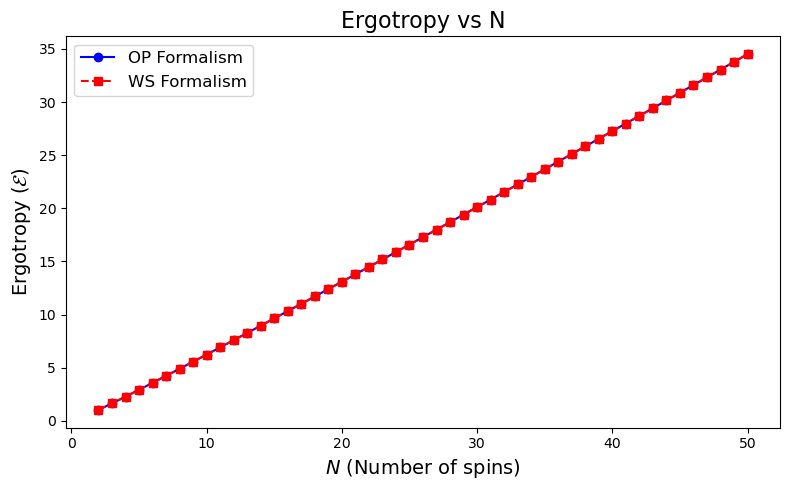

In [27]:
#########################################################
# Plot 1: Ergotropy (1st Moment) vs N
#########################################################
plt.figure(figsize=(8, 5))
plt.plot(N_arr, erg_OP, 'o-', color='blue', label='OP Formalism', markersize=6)
plt.plot(N_arr, erg_WS, 's--', color='red', label='WS Formalism', markersize=6)

plt.xlabel(r"$N$ (Number of spins)", fontsize=14)
plt.ylabel(r"Ergotropy ($\mathcal{E})$", fontsize=14)
plt.title(r"Ergotropy vs N", fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

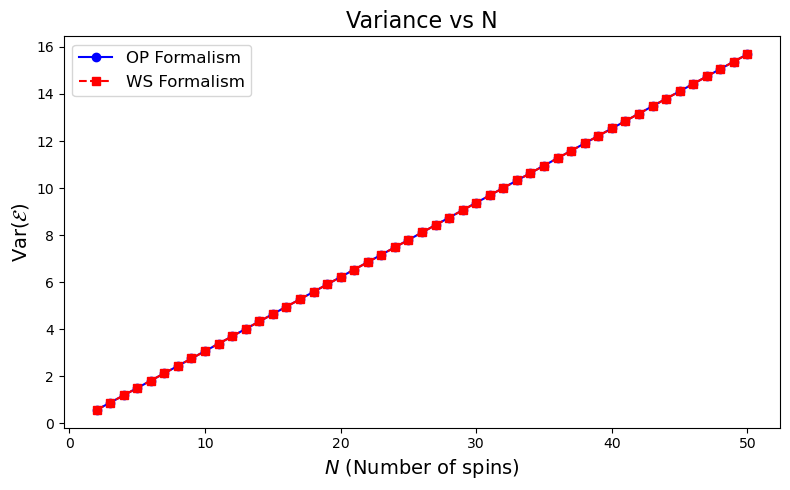

In [25]:
#########################################################
# Plot 2: Variance (2nd Moment) vs N
#########################################################
plt.figure(figsize=(8, 5))
plt.plot(N_arr, var_OP, 'o-', color='blue', label='OP Formalism', markersize=6)
plt.plot(N_arr, var_WS, 's--', color='red', label='WS Formalism', markersize=6)

plt.xlabel(r"$N$ (Number of spins)", fontsize=14)
plt.ylabel(r"$\mathrm{Var}(\mathcal{E})$", fontsize=14)
plt.title(r"Variance vs N", fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

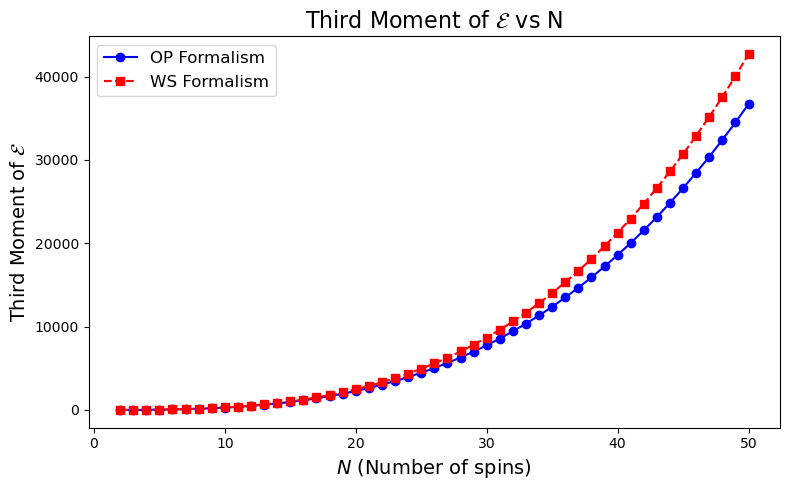

In [23]:
#########################################################
# Plot 3: Third Moment vs N
#########################################################
plt.figure(figsize=(8, 5))
plt.plot(N_arr, third_OP, 'o-', color='blue', label='OP Formalism', markersize=6)
plt.plot(N_arr, third_WS, 's--', color='red', label='WS Formalism', markersize=6)

plt.xlabel(r"$N$ (Number of spins)", fontsize=14)
plt.ylabel(r"Third Moment of $\mathcal{E}$", fontsize=14)
plt.title(r"Third Moment of $\mathcal{E}$ vs N", fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()